# Homework 6: Probability, Simulation, Estimation, and Assessing Models

Please complete this notebook by filling in the cells provided. Before you begin, execute the previous cell to load the provided tests.

**Helpful Resource:**
- [Python Reference](http://data8.org/sp22/python-reference.html): Cheat sheet of helpful array & table methods.

**Recommended Readings**: 
* [Randomness](https://www.inferentialthinking.com/chapters/09/Randomness.html)
* [Sampling and Empirical Distributions](https://www.inferentialthinking.com/chapters/10/Sampling_and_Empirical_Distributions.html)
* [Testing Hypotheses](https://www.inferentialthinking.com/chapters/11/Testing_Hypotheses.html)

Please complete this notebook by filling in the cells provided. Before you begin, execute the following cell to setup the notebook by importing some helpful libraries. Each time you start your server, you will need to execute this cell again.

For all problems that you must write explanations and sentences for, you **must** provide your answer in the designated space. **Moreover, throughout this homework and all future ones, please be sure to not re-assign variables throughout the notebook!** For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!



## 1. Roulette

In [9]:
pip install datascience

Note: you may need to restart the kernel to use updated packages.


In [10]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import Table


# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

A Nevada roulette wheel has 38 pockets and a small ball that rests on the wheel. When the wheel is spun, the ball comes to rest in one of the 38 pockets. That pocket is declared the winner. 

The pockets are labeled 0, 00, 1, 2, 3, 4, ... , 36. Pockets 0 and 00 are green, and the other pockets are alternately red and black. The table `wheel` is a representation of a Nevada roulette wheel. **Note that *both* columns consist of strings.

Run the cell below to load the `wheel` table.

In [11]:
wheel = Table.read_table('roulette_wheel-1-1.csv', dtype=str)
wheel

Pocket,Color
00,green
0,green
1,red
2,black
3,red
4,black
5,red
6,black
7,red
8,black


### Betting on Red ###
If you bet on *red*, you are betting that the winning pocket will be red. This bet *pays 1 to 1*. That means if you place a one-dollar bet on red, then:

- If the winning pocket is red, you gain 1 dollar. That is, you get your original dollar back, plus one more dollar.
- if the winning pocket is not red, you lose your dollar. In other words, you gain -1 dollars.

Let's see if you can make money by betting on red at roulette.

**Question 1.** Define a function `dollar_bet_on_red` that takes the name of a color and returns your gain in dollars if that color had won and you had placed a one-dollar bet on red. Remember that the gain can be negative. Make sure your function returns an integer.

*Note:* You can assume that the only colors that will be passed as arguments are red, black, and green. Your function doesn't have to check that.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [12]:
""" # BEGIN PROMPT
def dollar_bet_on_red(...):
    ...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT

def dollar_bet_on_red(color):
    if color == 'red':
        return 1
    else:
        return -1

# END SOLUTION


**Question 2.** Add a column labeled `Winnings: Red` to the table `wheel`. For each pocket, the column should contain your gain in dollars if that pocket won and you had bet one dollar on red. Your code should use the function `dollar_bet_on_red`. 

Type your solution in the following cell. Be sure to include comments explaining your code.

In [13]:
wheel = wheel.with_column('Winnings: Red', wheel.apply(dollar_bet_on_red,'Color'))
wheel

Pocket,Color,Winnings: Red
00,green,-1
0,green,-1
1,red,1
2,black,-1
3,red,1
4,black,-1
5,red,1
6,black,-1
7,red,1
8,black,-1


END SOLUTION

### Simulating 10 Bets on Red
Roulette wheels are set up so that each time they are spun, the winning pocket is equally likely to be any of the 38 pockets regardless of the results of all other spins. Let's see what would happen if we decided to bet one dollar on red each round.

**Question 3.** Create a table `ten_bets` by sampling the table `wheel` to simulate 10 spins of the roulette wheel. Your table should have the same three column labels as in `wheel`. Once you've created that table, set `sum_bets` to your net gain in all 10 bets, assuming that you bet one dollar on red each time. 

*Hint:* It may be helpful to print out `ten_bets` after you create it!


Type your solution in the following cell. Be sure to include comments explaining your code.

In [14]:
ten_bets = wheel.sample(10)

sum_bets = ten_bets.column('Winnings: Red').sum()

sum_bets

-6

END SOLUTION

**Question 4.** Let's see what would happen if you made more bets. Define a function `net_gain_red` that takes the number of bets and returns the net gain in that number of one-dollar bets on red.

*Hint:* You should use your `wheel` table within your function.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [15]:
def net_gain_red(num):
    net_gain = wheel.sample(num).column('Winnings: Red').sum()
    return net_gain

END SOLUTION

**Question 5.** Complete the cell below to simulate the net gain in 200 one-dollar bets on red, repeating the process 10,000 times. After the cell is run, `all_gains_red` should be an array with 10,000 entries, each of which is the net gain in 200 one-dollar bets on red.

*Hint:* Think about which computational tool might be helpful for simulating a process multiple times. Lab 5 might be a good resource to look at!

*Note:* This cell might take a few seconds to run.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [16]:
num_bets = 200 
repetitions = 10000
all_gains_red = make_array()

for i in range(repetitions):
    all_gains_red = np.append(all_gains_red, net_gain_red(num_bets))

len(all_gains_red) # Do not change this line! Check that all_gains_red is length 10000.

10000

END SOLUTION

Run the cell below to visualize the results of your simulation.

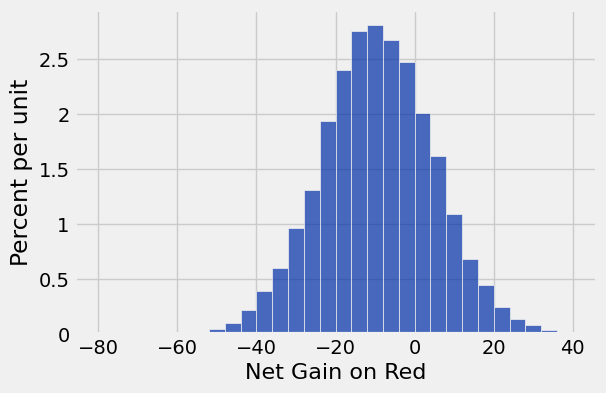

In [17]:
gains = Table().with_columns('Net Gain on Red', all_gains_red)
gains.hist(bins = np.arange(-80, 41, 4))
plt.show()

**Question 6:** Using the histogram above, decide whether the following statement is true or false:

>If you make 200 one-dollar bets on red, your chance of losing money is more than 50%.

Assign `loss_more_than_50` to either `True` or `False` depending on your answer to the question. 


Type your solution in the following cell. Be sure to include comments explaining your code.

In [18]:
loss_more_than_50 = True

END SOLUTION

### Betting on a Split ###
If betting on red doesn't seem like a good idea, maybe a gambler might want to try a different bet. A bet on a *split* is a bet on two consecutive numbers such as 5 and 6. This bets pays 17 to 1. That means if you place a one-dollar bet on the split 5 and 6, then:

- If the winning pocket is either 5 or 6, your gain is 17 dollars.
- If any other pocket wins, you lose your dollar, so your gain is -1 dollars.

**Question 7.** Define a function `dollar_bet_on_split` that takes a pocket number and returns your gain in dollars if that pocket won and you had bet one dollar on the 5-6 split. 

*Hint:* Remember that the pockets are represented as strings.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [19]:
def dollar_bet_on_split(pocket):
    if pocket == "5" or pocket == "6":
        return 17
    else:
        return -1

END SOLUTION

**Question 8.** Add a column `Winnings: Split` to the `wheel` table. For each pocket, the column should contain your gain in dollars if that pocket won and you had bet one dollar on the 5-6 split. 


Type your solution in the following cell. Be sure to include comments explaining your code.

In [20]:
wheel = wheel.with_column('Winnings: Split', wheel.apply(dollar_bet_on_split, 'Pocket'))

wheel.show(5) # Do not change this line.

Pocket,Color,Winnings: Red,Winnings: Split
00,green,-1,-1
0,green,-1,-1
1,red,1,-1
2,black,-1,-1
3,red,1,-1


END SOLUTION

**Question 9.** Simulate the net gain in 200 one-dollar bets on the 5-6 split, repeating the process 10,000 times and saving your gains in the array `all_gains_split`. 

*Hint:* Your code in Questions 4 and 5 may be helpful here!


Type your solution in the following cell. Be sure to include comments explaining your code.

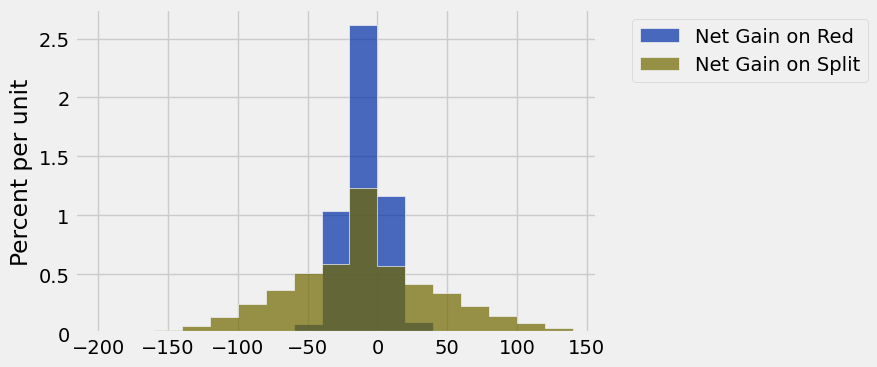

In [21]:
all_gains_split = make_array()

# BEGIN SOLUTION

def net_gain_split(num):
    split_gain = wheel.sample(num).column('Winnings: Split').sum()
    return split_gain

for i in range(repetitions):
    all_gains_split = np.append(all_gains_split, net_gain_split(num_bets))
    

# END SOLUTION

# Do not change the two lines below
gains = gains.with_columns('Net Gain on Split', all_gains_split)
gains.hist(bins = np.arange(-200, 150, 20))
plt.show()

END SOLUTION

**Question 10.** Look carefully at the visualization above, and assign `histogram_statements` to an array of the numbers of each statement below that can be correctly inferred from the overlaid histogram. 

1. If you bet one dollar 200 times on a split, your chance of losing money is more than 50%.
2. If you bet one dollar 200 times in roulette, your chance of making more than 50 dollars is greater if you bet on a split each time than if you bet on red each time.
3. If you bet one dollar 200 times in roulette, your chance of losing more than 50 dollars is greater if you bet on a split each time than if you bet on red each time.

*Hint:* We've already seen one of these statements in a prior question.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [22]:
histogram_statements = make_array(1, 2, 3)

END SOLUTION

## 2. Chances

Before you do this exercise, make sure you understand the logic behind all the examples in [Section 9.5](https://inferentialthinking.com/chapters/09/5/Finding_Probabilities.html). 

Good ways to approach probability calculations include:

- Thinking one trial at a time: What does the first one have to be? Then what does the next one have to be?
- Breaking up the event into distinct ways in which it can happen.
- Seeing if it is easier to find the chance that the event does not happen.

### Finding Chances

On each spin of a roulette wheel, all 38 pockets are equally likely to be the winner regardless of the results of other spins. Among the 38 pockets, 18 are red, 18 black, and 2 green. In each part below, write an expression that evaluates to the chance of the event described.

**Question 1.** The winning pocket is black on all of the first three spins. 


Type your solution in the following cell. Be sure to include comments explaining your code.

In [26]:
18/38 ** 3

0.0003280361568741799

**Question 2.** The color green never wins in the first 10 spins. 


BEGIN SOLUTION

**Question 3.** The color green wins at least once on the first 10 spins. 


Type your solution in the following cell. Be sure to include comments explaining your code.

In [24]:
1-(36/38)**10

0.41764334677006076

END SOLUTION

**Question 4.** Two of the three colors never win in the first 10 spins.

*Hint:* Imagine the event with the colors red, yellow, and orange. What situation(s) lead to two of the three colors never winning in the first 10 spins?


Type your solution in the following cell. Be sure to include comments explaining your code.

In [25]:
(2/38)**10 + 2(18/38)**10

<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
C:\Users\aksha\AppData\Local\Temp\ipykernel_15144\676014904.py:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
  (2/38)**10 + 2(18/38)**10


TypeError: 'int' object is not callable

END SOLUTION

### Comparing Chances
In each of Questions 5-7, two events A and B are described. Choose from one of the following three options and set each answer variable to a single integer:

1. Event A is more likely than Event B
2. Event B is more likely than Event A
3. The two events have the same chance.

You should be able to make the choices **without calculation**. Good ways to approach this exercise include imagining carrying out the chance experiments yourself, one trial at a time, and by thinking about the [law of averages](https://inferentialthinking.com/chapters/10/1/Empirical_Distributions.html#the-law-of-averages).

**Question 5.** A child picks four times at random from a box that has four toy animals: a bear, an elephant, a giraffe, and a kangaroo. 

- Event A: all four different animals are picked (assuming the child picks without replacement)
- Event B: all four different animals are picked (assuming the child picks with replacement)


Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
answerQ5 = 1

END SOLUTION

**Question 6.** In a lottery, two numbers are drawn at random with replacement from the integers 1 through 1000. 
- Event A: The number 8 is picked on both draws
- Event B: The same number is picked on both draws


Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
answerQ6 = 3

END SOLUTION

**Question 7.** A fair coin is tossed repeatedly. 

- Event A: There are 60 or more heads in 100 tosses
- Event B: There are 600 or more heads in 1000 tosses

*Hint*: Think about the law of averages!


Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
answerQ7 = 1

END SOLUTION

## 3. Three Ways Python Draws Random Samples

You have learned three ways to draw random samples using Python:

- `tbl.sample` draws a random sample of rows from the table `tbl`. The output is a table consisting of the sampled rows. 

- `np.random.choice` draws a random sample from a population whose elements are in an array. The output is an array consisting of the sampled elements.

- `sample_proportions` draws from a categorical distribution whose proportions are in an array. The output is an array consisting of the sampled proportions in all the categories. 

In [ ]:
# Look through this code and run this cell for questions 1 and 2
top = Table.read_table('top_movies_2017.csv').select(0, 1)
top.show(3)

Title,Studio
Gone with the Wind,MGM
Star Wars,Fox
The Sound of Music,Fox


In [ ]:
# Look through this code and run this cell for questions 1 and 2
studios_with_counts = top.group('Studio').sort('count', descending=True)
studios_with_counts.show(3)

Studio,count
Buena Vista,35
Warner Brothers,29
Paramount,25


In [ ]:
# Look through this code and run this cell for questions 1 and 2
studios_of_all_movies = top.column('Studio')
distinct_studios = studios_with_counts.column('Studio')

print("studios_of_all_movies:", studios_of_all_movies[:10], "...")
print("\n distinct_studios:", distinct_studios)

studios_of_all_movies: ['MGM' 'Fox' 'Fox' 'Universal' 'Paramount' 'Paramount' 'Universal' 'MGM'
 'Warner Brothers' 'Disney'] ...

 distinct_studios: ['Buena Vista' 'Warner Brothers' 'Paramount' 'Fox' 'Universal' 'Disney'
 'Columbia' 'MGM' 'United Artists' 'Newline' 'Paramount/Dreamworks' 'Sony'
 'Dreamworks' 'Lionsgate' 'RKO' 'Tristar' 'AVCO' 'IFC' 'Metro' 'NM' 'Orion'
 'Selz.' 'Sum.']


In [ ]:
# Look through this code and run this cell for questions 1 and 2
studio_counts_only = studios_with_counts.column('count')
studio_proportions_only = studio_counts_only / sum(studio_counts_only)

print("studio_counts_only:", studio_counts_only)
print("\n studio_proportions_only:", studio_proportions_only)

studio_counts_only: [35 29 25 24 23 11  9  7  6  5  4  4  3  3  3  2  1  1  1  1  1  1  1]

 studio_proportions_only: [ 0.175  0.145  0.125  0.12   0.115  0.055  0.045  0.035  0.03   0.025
  0.02   0.02   0.015  0.015  0.015  0.01   0.005  0.005  0.005  0.005
  0.005  0.005  0.005]


In Questions 1 and 2, we will present a scenario. Determine which three of the following six options are true in regards to what the question is asking, and list them in the following answer cell. If your answer includes any of (i)-(iii), state what you would fill in the blank to make it true: `top`, `studios_with_counts`, `studios_of_all_movies`, `distinct_studios`, `studio_counts_only` or `studio_proportions_only`.

(i) This can be done using `sample` and the table _________.

(ii) This can be done using `np.random.choice` and the array ________.

(iii) This can be done using `sample_proportions` and the array _______.

(iv) This cannot be done using `sample` and the data given.

(v) This cannot be done using `np.random.choice` and the data given.

(vi) This cannot be done using `sample_proportions` and the data given.

**Question 1.** Simulate a sample of 10 movies drawn at random with replacement from the 200 movies. Outputs True if Paramount appears more often than Warner Brothers among studios that released the sampled movies, and False otherwise. 

*Example Answer:* (i) studios_of_all_movies, (iii) top, (v)

***Note***: Do not explain your answer for any of the options you've chosen; please follow the structure of the example answer provided.


Type your solution in the following cell. Be sure to include comments explaining your code.

(i) top, (ii) studio_of_all_movies, (vi)

END SOLUTION

## 4. Assessing Jade's Models

Before you begin, [Section 10.4](https://inferentialthinking.com/chapters/10/4/Random_Sampling_in_Python.html) of the textbook is a useful reference for this part.

### Games with Jade
Our friend Jade comes over and asks us to play a game with her. The game works like this: 

> We will draw randomly with replacement from a simplified 13 card deck with 4 face cards (A, J, Q, K), and 9 numbered cards (2, 3, 4, 5, 6, 7, 8, 9, 10). If we draw cards with replacement 13 times, and if the number of face cards is greater than or equal to 4, we lose.
> 
> Otherwise, Jade loses.

We play the game once and we lose, observing 8 total face cards. We are angry and accuse Jade of cheating! Jade is adamant, however, that the deck is fair.

Jade's model claims that there is an equal chance of getting any of the cards (A, 2, 3, 4, 5, 6, 7, 8, 9, 10, J, Q, K), but we do not believe her. We believe that the deck is clearly rigged, with face cards (A, J, Q, K) being more likely than the numbered cards (2, 3, 4, 5, 6, 7, 8, 9, 10).

**Question 1.** Assign `deck_model_probabilities` to a two-item array containing the chance of drawing a face card as the first element, and the chance of drawing a numbered card as the second element under Jade's model. Since we're working with probabilities, make sure your values are between 0 and 1.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
deck_model_probabilities = make_array(4/13, 9/13)

deck_model_probabilities

array([ 0.30769231,  0.69230769])

END SOLUTION

**Question 2.** We believe Jade's model is incorrect. In particular, we believe there to be a *larger* chance of getting a face card. Which of the following statistics can we use during our simulation to test between the model and our alternative? Assign `statistic_choice` to the correct answer.

1. The distance (absolute value) between the actual number of face cards in 13 draws and 4, the expected number of face cards in 13 draws
2. The expected number of face cards in 13 draws, 4
3. The number of face cards we get in 13 draws


Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:

statistic_choice = 1

END SOLUTION

**Question 3.** Define the function `deck_simulation_and_statistic`, which, given a sample size and an array of model proportions (like the one you created in Question 1), returns the number of face cards in one simulation of drawing cards under the model specified in `model_proportions`. 

*Hint:* Think about how you can use the function `sample_proportions`. 


BEGIN SOLUTION

In [ ]:
def deck_simulation_and_statistic(sample_size, model_proportions):
    # BEGIN SOLUTION
    result = sample_proportions(sample_size, model_proportions)
    face_cards = result.item(0) * sample_size
    return face_cards

    # END SOLUTION

deck_simulation_and_statistic(13, deck_model_probabilities)

4.0

END SOLUTION

**Question 4.** Use your function from above to simulate the drawing of 13 cards 5000 times under the proportions that you specified in Question 1. Keep track of all of your statistics in `deck_statistics`.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [ ]:
repetitions = 5000 
# BEGIN SOLUTION

deck_statistics = make_array()
for i in range(repetitions):
    deck_statistics = np.append(deck_statistics, deck_simulation_and_statistic(13, deck_model_probabilities))

# END SOLUTION

deck_statistics

array([ 2.,  7.,  6., ...,  4.,  4.,  4.])

END SOLUTION

Let’s take a look at the distribution of simulated statistics.

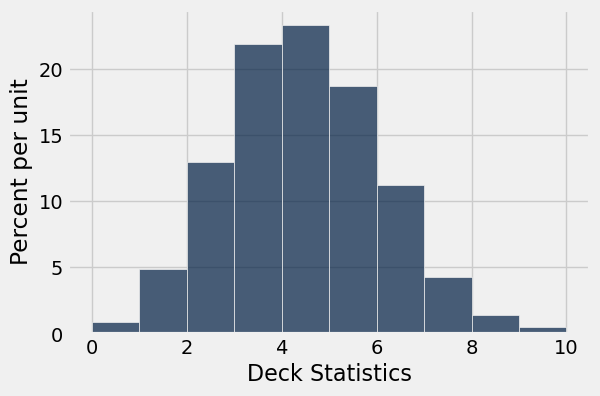

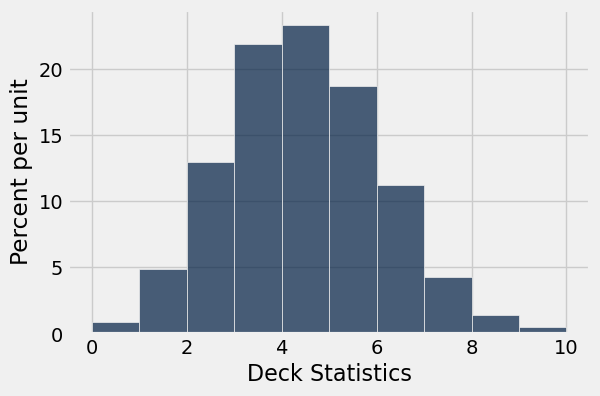

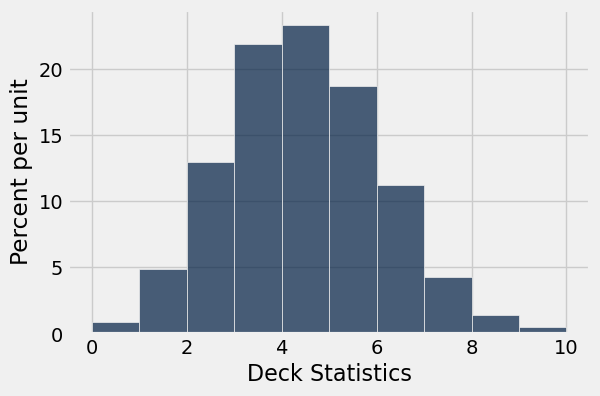

In [ ]:
# Draw a distribution of statistics 
Table().with_column('Deck Statistics', deck_statistics).hist()
plt.show()

**Question 5.** Given your observed value, do you believe that Jade's model is reasonable, or is our alternative (that our deck is rigged) more likely? Explain your answer using the histogram produced above. 


Type your solution in the following cell. Be sure to include comments explaining your code.

I believe it is hard to say, given we have one real life experiment. Given the one experiment, it is more likey that the deck is rigged. Jade's model produces 8 face cards a very small amount of times given a large sample. This leads me to suspect the deck is rigged.

END SOLUTION

You're done with Homework 6!  